# EDA Question 2: Seasonal Patterns Analysis
## Amazon India Sales Analytics

**Objective:** Analyze seasonal patterns in sales data. Create monthly sales heatmaps and identify peak selling months. Compare seasonal trends across different years and subcategories.

**Analysis Components:**
- Monthly sales aggregation and pattern identification
- Heatmap visualization of sales by year and month
- Peak selling month identification
- Seasonal trend comparison across years
- Subcategory-wise seasonal analysis
- Festival and seasonal impact assessment

## Section 1: Load Data and Setup

Import required libraries and load the cleaned dataset for seasonal analysis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from calendar import month_abbr
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

# Load the cleaned dataset
df = pd.read_csv('../data/cleaned/amazon_india_all_years_cleaned.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print(f"\nDate Range: {df['order_year'].min()}-{df['order_year'].max()}")
print(f"Total Records: {len(df):,}")
print(f"\nColumns for Seasonal Analysis:")
print("  • order_year")
print("  • order_month")
print("  • order_quarter")
print("  • subcategory")
print("  • final_amount_inr")
print("  • is_festival_sale")
print("  • festival_name")
print("\n✓ Data loaded successfully")

Dataset Shape: (1122687, 51)

Date Range: 2015-2025
Total Records: 1,122,687

Columns for Seasonal Analysis:
  • order_year
  • order_month
  • order_quarter
  • category
  • final_amount_inr
  • is_festival_sale
  • festival_name

✓ Data loaded successfully


## Section 2: Monthly Sales Aggregation

Aggregate sales data by year and month to identify seasonal patterns.

In [2]:
# Aggregate sales by year and month
monthly_sales = df.groupby(['order_year', 'order_month']).agg({
    'final_amount_inr': 'sum',
    'transaction_id': 'count'
}).reset_index()

monthly_sales.columns = ['Year', 'Month', 'Total_Revenue', 'Transaction_Count']

# Calculate average order value per month
monthly_sales['Avg_Order_Value'] = monthly_sales['Total_Revenue'] / monthly_sales['Transaction_Count']

# Create month name for better readability
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_sales['Month_Name'] = monthly_sales['Month'].map(month_names)

# Sort by year and month
monthly_sales = monthly_sales.sort_values(['Year', 'Month']).reset_index(drop=True)

print("=" * 100)
print("MONTHLY SALES SUMMARY")
print("=" * 100)
print(f"\nTotal Months Analyzed: {len(monthly_sales)}")
print(f"Years: {monthly_sales['Year'].min()} to {monthly_sales['Year'].max()}")
print(f"\nSample Data:")
print(monthly_sales.head(15).to_string(index=False))

# Overall monthly statistics
print("\n" + "=" * 100)
print("OVERALL MONTHLY STATISTICS (All Years Combined)")
print("=" * 100)
overall_monthly = df.groupby('order_month').agg({
    'final_amount_inr': ['sum', 'mean'],
    'transaction_id': 'count'
}).reset_index()
overall_monthly.columns = ['Month', 'Total_Revenue', 'Avg_Revenue_Per_Transaction', 'Total_Transactions']
overall_monthly['Month_Name'] = overall_monthly['Month'].map(month_names)
overall_monthly = overall_monthly.sort_values('Total_Revenue', ascending=False)

print("\nMonthly Sales Ranking (All Years):")
print(overall_monthly[['Month_Name', 'Total_Revenue', 'Total_Transactions']].to_string(index=False))

print("\n✓ Monthly aggregation complete")

MONTHLY SALES SUMMARY

Total Months Analyzed: 132
Years: 2015 to 2025

Sample Data:
 Year  Month  Total_Revenue  Transaction_Count  Avg_Order_Value Month_Name
 2015      1   162510738.05               2402     67656.427165        Jan
 2015      2   143331184.38               2102     68188.003987        Feb
 2015      3   144819343.85               2402     60291.150645        Mar
 2015      4   177071348.29               2401     73748.999704        Apr
 2015      5   156298488.64               2701     57866.896942        May
 2015      6   139240664.25               2402     57968.636241        Jun
 2015      7   154441761.55               2701     57179.474843        Jul
 2015      8   169952333.00               2401     70783.978759        Aug
 2015      9   170224976.37               2701     63022.945713        Sep
 2015     10   211071664.26               3903     54079.340061        Oct
 2015     11   231836077.43               3302     70210.804794        Nov
 2015     12   2

## Section 3: Sales Heatmap Visualization

Create comprehensive heatmaps showing sales patterns across years and months.

✓ Heatmap saved as 'Q02_Monthly_Sales_Heatmap.png'


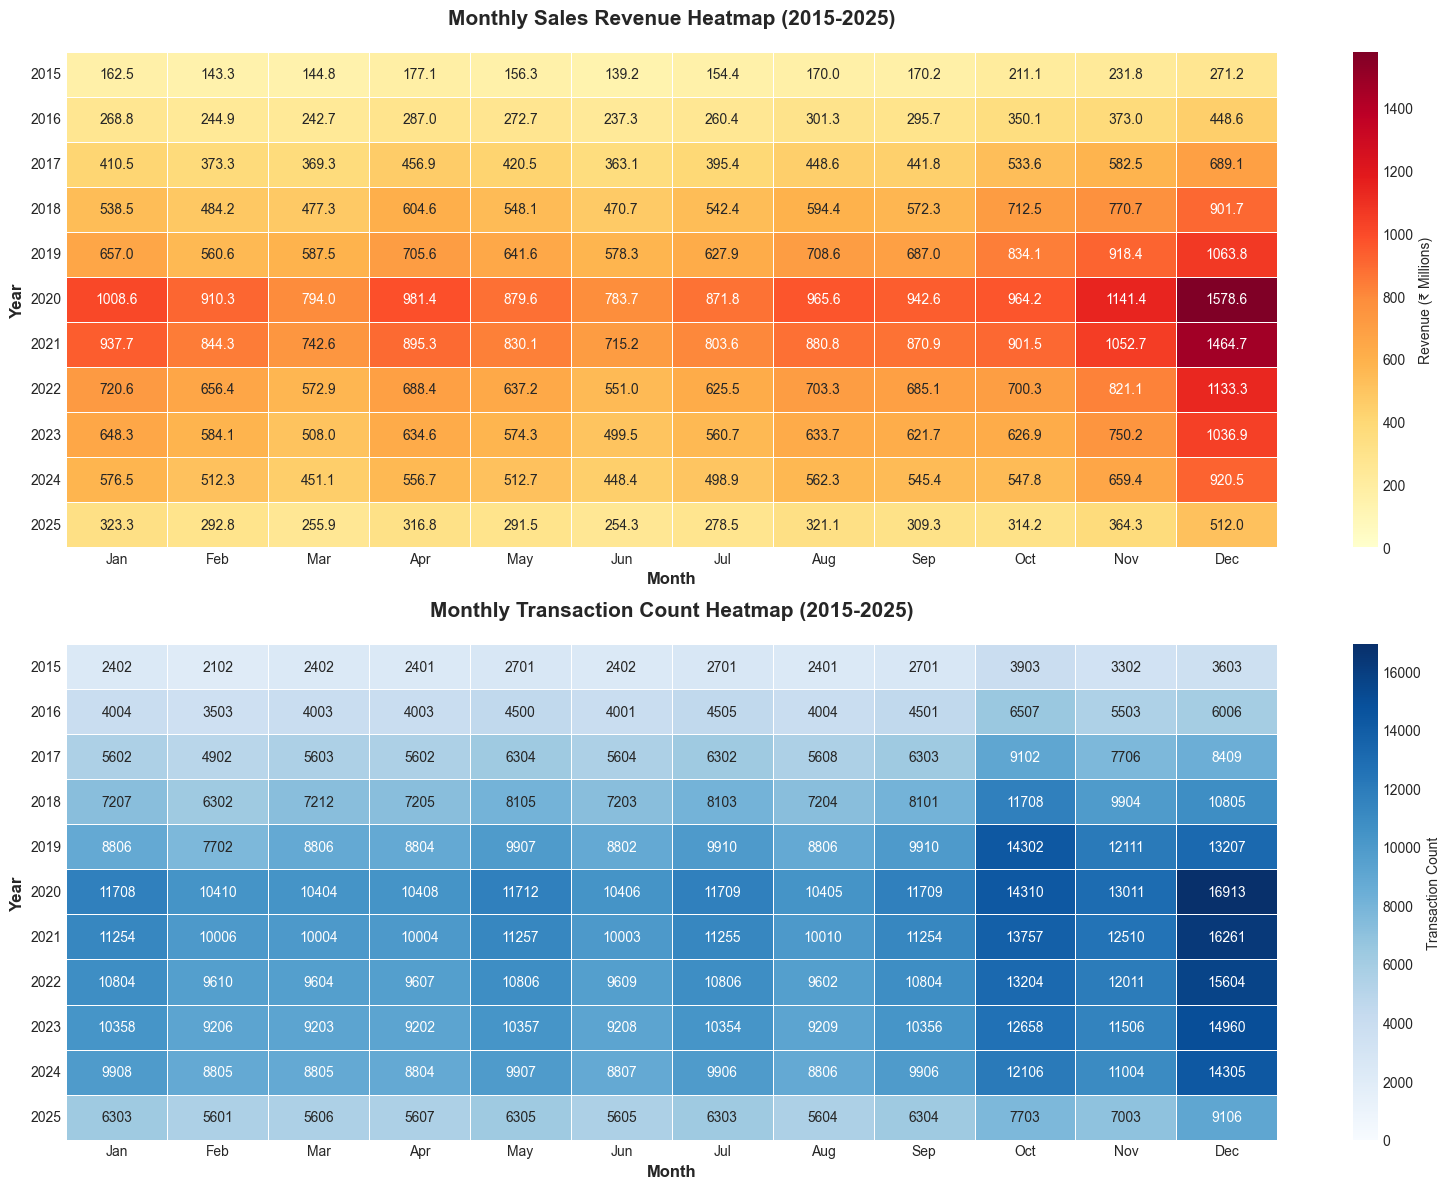


PEAK SELLING MONTHS IDENTIFICATION

Peak Month by Year:
 Year Month_Name  Total_Revenue  Transaction_Count
 2015        Dec   2.711721e+08               3603
 2016        Dec   4.485769e+08               6006
 2017        Dec   6.891474e+08               8409
 2018        Dec   9.016504e+08              10805
 2019        Dec   1.063762e+09              13207
 2020        Dec   1.578594e+09              16913
 2021        Dec   1.464743e+09              16261
 2022        Dec   1.133256e+09              15604
 2023        Dec   1.036910e+09              14960
 2024        Dec   9.205251e+08              14305
 2025        Dec   5.119703e+08               9106

----------------------------------------------------------------------------------------------------
Top 5 Peak Months (Across All Years):
 Year Month_Name  Total_Revenue  Transaction_Count
 2020        Dec   1.578594e+09              16913
 2021        Dec   1.464743e+09              16261
 2020        Nov   1.141400e+09       

In [3]:
# Create pivot table for heatmap
heatmap_data = monthly_sales.pivot(index='Year', columns='Month', values='Total_Revenue')
heatmap_data = heatmap_data / 1_000_000  # Convert to millions

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Heatmap 1: Revenue by Year and Month
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, 
            cbar_kws={'label': 'Revenue (₹ Millions)'}, ax=ax1, vmin=0)
ax1.set_title('Monthly Sales Revenue Heatmap (2015-2025)', fontsize=15, fontweight='bold', pad=20)
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Year', fontsize=12, fontweight='bold')
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)

# Heatmap 2: Transaction Count by Year and Month
heatmap_transactions = monthly_sales.pivot(index='Year', columns='Month', values='Transaction_Count')
sns.heatmap(heatmap_transactions, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': 'Transaction Count'}, ax=ax2, vmin=0)
ax2.set_title('Monthly Transaction Count Heatmap (2015-2025)', fontsize=15, fontweight='bold', pad=20)
ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Year', fontsize=12, fontweight='bold')
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../data/cleaned/Q02_Monthly_Sales_Heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Heatmap saved as 'Q02_Monthly_Sales_Heatmap.png'")
plt.show()

# Identify peak months
print("\n" + "=" * 100)
print("PEAK SELLING MONTHS IDENTIFICATION")
print("=" * 100)

# Find peak month for each year
peak_months = monthly_sales.loc[monthly_sales.groupby('Year')['Total_Revenue'].idxmax()]
print("\nPeak Month by Year:")
print(peak_months[['Year', 'Month_Name', 'Total_Revenue', 'Transaction_Count']].to_string(index=False))

# Overall peak months across all years
print("\n" + "-" * 100)
print("Top 5 Peak Months (Across All Years):")
top_months = monthly_sales.nlargest(5, 'Total_Revenue')[['Year', 'Month_Name', 'Total_Revenue', 'Transaction_Count']]
print(top_months.to_string(index=False))

## Section 4: Seasonal Trend Comparison Across Years

Compare seasonal patterns and trends across different years.


✓ Seasonal trends comparison saved as 'Q02_Seasonal_Trends_Comparison.png'


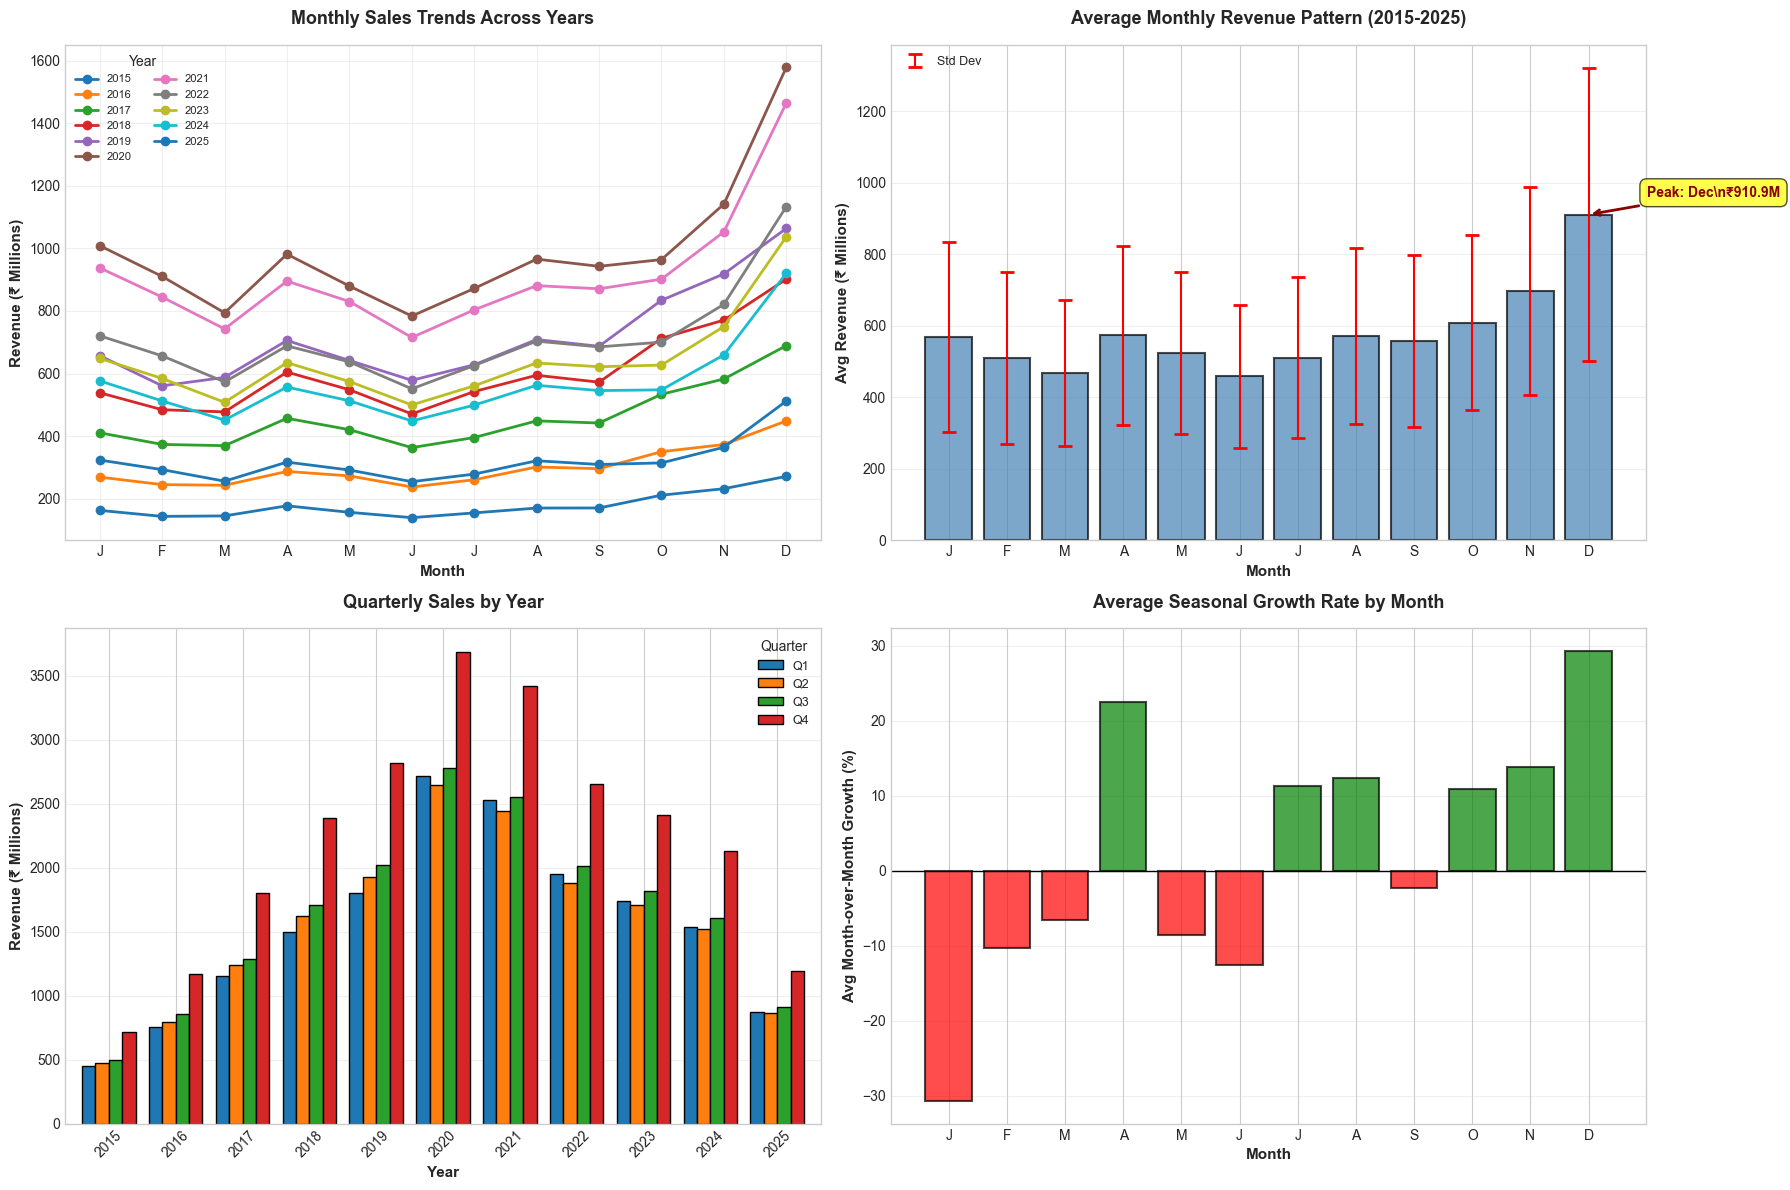


SEASONAL INSIGHTS

Peak Sales Month (Average): Dec (₹910.94M)
Lowest Sales Month (Average): Jun (₹458.24M)
Seasonal Volatility (Std Dev): ±₹253.45M


In [4]:
# Create seasonal comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Monthly Sales Trend by Year
ax1 = axes[0, 0]
for year in sorted(monthly_sales['Year'].unique()):
    year_data = monthly_sales[monthly_sales['Year'] == year]
    ax1.plot(year_data['Month'], year_data['Total_Revenue'] / 1_000_000, 
             marker='o', linewidth=2, label=str(int(year)), markersize=6)

ax1.set_xlabel('Month', fontsize=11, fontweight='bold')
ax1.set_ylabel('Revenue (₹ Millions)', fontsize=11, fontweight='bold')
ax1.set_title('Monthly Sales Trends Across Years', fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax1.legend(title='Year', loc='upper left', ncol=2, fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Average Monthly Revenue Pattern (All Years)
ax2 = axes[0, 1]
avg_monthly_revenue = monthly_sales.groupby('Month')['Total_Revenue'].mean() / 1_000_000
std_monthly_revenue = monthly_sales.groupby('Month')['Total_Revenue'].std() / 1_000_000
months = avg_monthly_revenue.index

ax2.bar(months, avg_monthly_revenue, alpha=0.7, color='steelblue', edgecolor='black', linewidth=1.5)
ax2.errorbar(months, avg_monthly_revenue, yerr=std_monthly_revenue, fmt='none', 
             ecolor='red', capsize=5, capthick=2, label='Std Dev')
ax2.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('Avg Revenue (₹ Millions)', fontsize=11, fontweight='bold')
ax2.set_title('Average Monthly Revenue Pattern (2015-2025)', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Annotate peak month
peak_month_avg = avg_monthly_revenue.idxmax()
peak_value = avg_monthly_revenue.max()
ax2.annotate(f'Peak: {month_names[peak_month_avg]}\\n₹{peak_value:.1f}M', 
             xy=(peak_month_avg, peak_value), xytext=(peak_month_avg+1, peak_value+50),
             fontsize=10, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=2))

# Plot 3: Quarterly Sales Comparison
ax3 = axes[1, 0]
quarterly_sales = df.groupby(['order_year', 'order_quarter'])['final_amount_inr'].sum().reset_index()
quarterly_sales.columns = ['Year', 'Quarter', 'Total_Revenue']
quarterly_sales['Total_Revenue'] = quarterly_sales['Total_Revenue'] / 1_000_000

quarterly_pivot = quarterly_sales.pivot(index='Year', columns='Quarter', values='Total_Revenue')
quarterly_pivot.plot(kind='bar', ax=ax3, width=0.8, edgecolor='black', linewidth=1)
ax3.set_xlabel('Year', fontsize=11, fontweight='bold')
ax3.set_ylabel('Revenue (₹ Millions)', fontsize=11, fontweight='bold')
ax3.set_title('Quarterly Sales by Year', fontsize=13, fontweight='bold', pad=15)
ax3.legend(title='Quarter', labels=['Q1', 'Q2', 'Q3', 'Q4'], fontsize=9)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Season-over-Season Growth Rate
ax4 = axes[1, 1]
monthly_sales_sorted = monthly_sales.sort_values(['Year', 'Month']).reset_index(drop=True)
monthly_sales_sorted['MoM_Growth'] = monthly_sales_sorted['Total_Revenue'].pct_change() * 100

# Calculate average seasonal growth by month
seasonal_growth = monthly_sales_sorted.groupby('Month')['MoM_Growth'].mean()
colors_growth = ['green' if x > 0 else 'red' for x in seasonal_growth.values]

ax4.bar(seasonal_growth.index, seasonal_growth.values, color=colors_growth, alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_xlabel('Month', fontsize=11, fontweight='bold')
ax4.set_ylabel('Avg Month-over-Month Growth (%)', fontsize=11, fontweight='bold')
ax4.set_title('Average Seasonal Growth Rate by Month', fontsize=13, fontweight='bold', pad=15)
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/cleaned/Q02_Seasonal_Trends_Comparison.png', dpi=300, bbox_inches='tight')
print("\n✓ Seasonal trends comparison saved as 'Q02_Seasonal_Trends_Comparison.png'")
plt.show()

print("\n" + "=" * 100)
print("SEASONAL INSIGHTS")
print("=" * 100)
print(f"\nPeak Sales Month (Average): {month_names[peak_month_avg]} (₹{peak_value:.2f}M)")
print(f"Lowest Sales Month (Average): {month_names[avg_monthly_revenue.idxmin()]} (₹{avg_monthly_revenue.min():.2f}M)")
print(f"Seasonal Volatility (Std Dev): ±₹{std_monthly_revenue.mean():.2f}M")

## Section 5: Subcategory-wise Seasonal Analysis

Analyze seasonal patterns across different product subcategories.

SUBCATEGORY-WISE SEASONAL PATTERNS

Top 5 Subcategories by Revenue:
  1. Smartphones: ₹55,907,196,873
  2. Laptops: ₹9,358,928,431
  3. Tablets: ₹5,061,853,340
  4. Smart Watch: ₹3,200,136,642
  5. TV & Entertainment: ₹1,913,436,926

✓ Subcategory-wise seasonal patterns saved as 'Q02_Subcategory_Seasonal_Patterns.png'


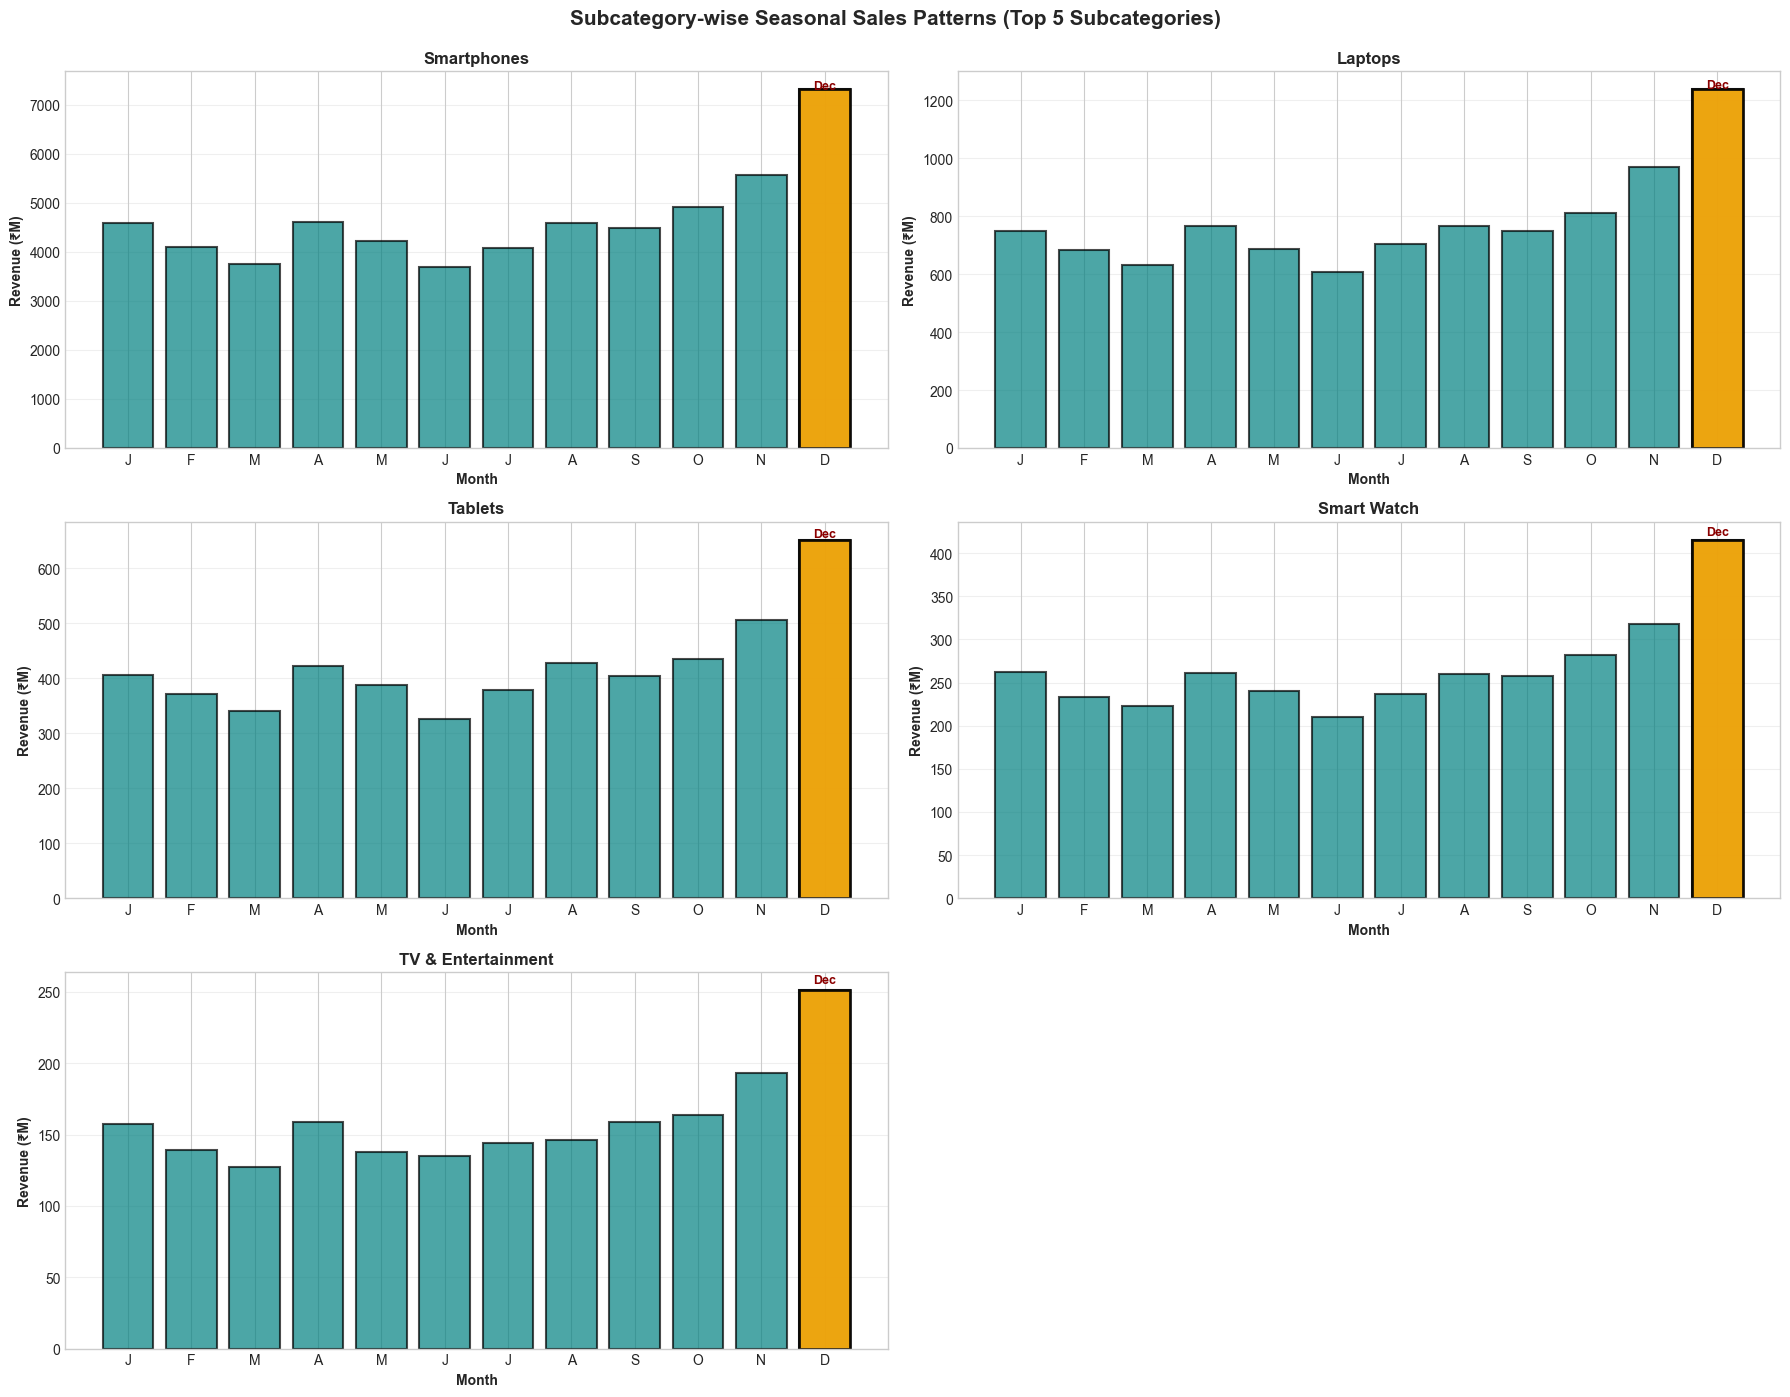


----------------------------------------------------------------------------------------------------
Peak Selling Months by Subcategory:
----------------------------------------------------------------------------------------------------
  • Smartphones: Dec (₹7,314,479,566)
  • Laptops: Dec (₹1,237,608,246)
  • Tablets: Dec (₹652,421,760)
  • Smart Watch: Dec (₹415,521,230)
  • TV & Entertainment: Dec (₹251,328,119)


In [9]:
# Top subcategories by revenue
top_subcategories = df.groupby('subcategory')['final_amount_inr'].sum().nlargest(5).index.tolist()

# Subcategory-wise monthly sales
subcategory_monthly = df.groupby(['subcategory', 'order_month']).agg({
    'final_amount_inr': 'sum',
    'transaction_id': 'count'
}).reset_index()
subcategory_monthly.columns = ['Subcategory', 'Month', 'Total_Revenue', 'Transaction_Count']

print("=" * 100)
print("SUBCATEGORY-WISE SEASONAL PATTERNS")
print("=" * 100)
print(f"\nTop 5 Subcategories by Revenue:")
for i, subcat in enumerate(top_subcategories, 1):
    subcat_revenue = df[df['subcategory'] == subcat]['final_amount_inr'].sum()
    print(f"  {i}. {subcat}: ₹{subcat_revenue:,.0f}")

# Create subcategory-wise heatmaps
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, subcategory in enumerate(top_subcategories):
    subcat_data = subcategory_monthly[subcategory_monthly['Subcategory'] == subcategory]
    
    # Create monthly revenue for this subcategory
    monthly_subcat_revenue = subcat_data.groupby('Month')['Total_Revenue'].sum() / 1_000_000
    
    # Ensure all 12 months are present
    all_months = pd.Series(0.0, index=range(1, 13), dtype='float64')
    for month, revenue in monthly_subcat_revenue.items():
        all_months[month] = revenue
    
    # Plot bar chart
    axes[idx].bar(all_months.index, all_months.values, color='teal', alpha=0.7, 
                  edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{subcategory}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Month', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Revenue (₹M)', fontsize=10, fontweight='bold')
    axes[idx].set_xticks(range(1, 13))
    axes[idx].set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Highlight peak month
    peak_month = all_months.idxmax()
    peak_val = all_months.max()
    axes[idx].bar(peak_month, peak_val, color='orange', alpha=0.9, edgecolor='black', linewidth=2)
    axes[idx].text(peak_month, peak_val + 5, f'{month_names[peak_month]}', 
                   ha='center', fontsize=9, fontweight='bold', color='darkred')

# Remove the 6th subplot if only 5 subcategories
if len(top_subcategories) < 6:
    fig.delaxes(axes[5])

plt.suptitle('Subcategory-wise Seasonal Sales Patterns (Top 5 Subcategories)', 
             fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../data/cleaned/Q02_Subcategory_Seasonal_Patterns.png', dpi=300, bbox_inches='tight')
print("\n✓ Subcategory-wise seasonal patterns saved as 'Q02_Subcategory_Seasonal_Patterns.png'")
plt.show()

# Identify peak months for each subcategory
print("\n" + "-" * 100)
print("Peak Selling Months by Subcategory:")
print("-" * 100)
for subcategory in top_subcategories:
    subcat_data = subcategory_monthly[subcategory_monthly['Subcategory'] == subcategory]
    peak_month_idx = subcat_data.loc[subcat_data['Total_Revenue'].idxmax(), 'Month']
    peak_revenue = subcat_data['Total_Revenue'].max()
    print(f"  • {subcategory}: {month_names[peak_month_idx]} (₹{peak_revenue:,.0f})")

## Section 6: Festival Impact Analysis

Analyze the impact of festivals on seasonal sales patterns.

FESTIVAL IMPACT ON SALES

Festival Sales: ₹16,544,767,969 (21.61% of total)
Non-Festival Sales: ₹60,002,800,077 (78.39% of total)

Festival Transactions: 348,389 (31.03% of total)
Non-Festival Transactions: 774,298 (68.97% of total)

Avg Order Value (Festival): ₹47,489.35
Avg Order Value (Non-Festival): ₹77,493.16
Festival Premium: -38.72%

----------------------------------------------------------------------------------------------------
Festival-wise Sales Breakdown:
----------------------------------------------------------------------------------------------------
                    Festival  Total_Revenue  Transaction_Count  Avg_Order_Value
              Back to School   4.055227e+09              85018     47698.451975
                 Diwali Sale   3.941429e+09              83247     47346.193644
Amazon Great Indian Festival   2.507761e+09              52855     47446.052253
                 Summer Sale   2.110697e+09              44748     47168.510995
               Holi Fest

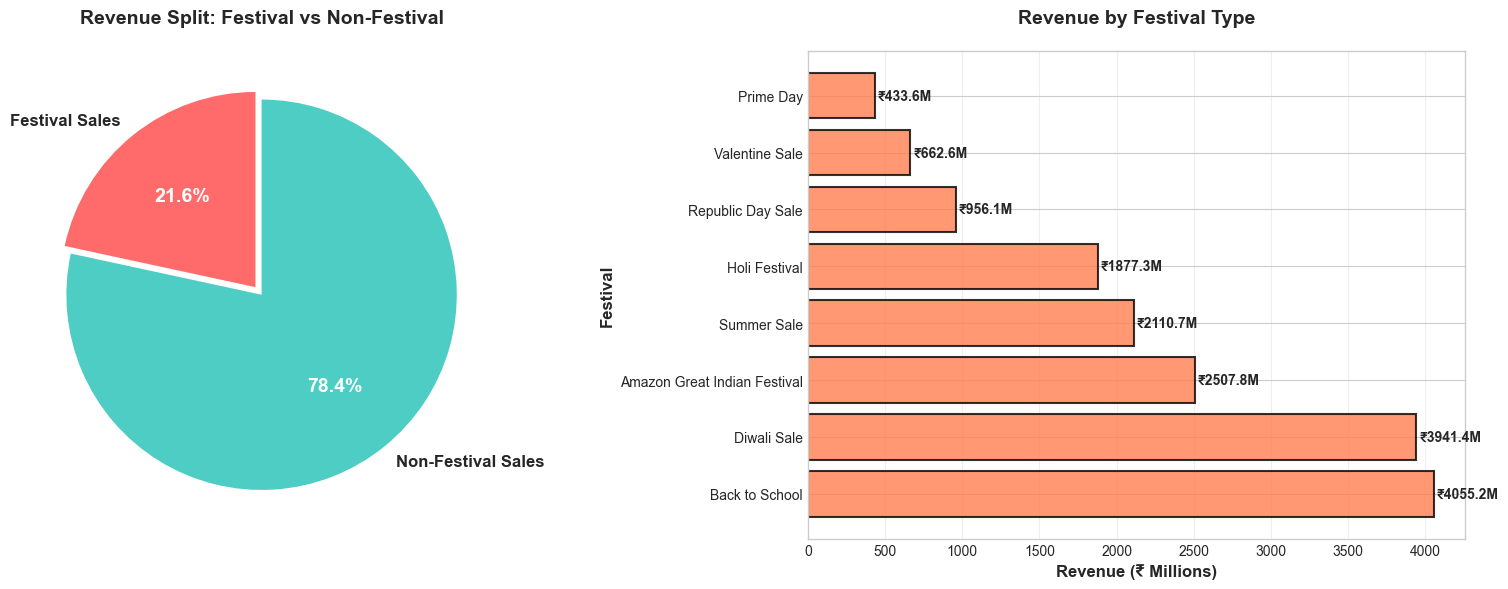

In [7]:
# Festival vs Non-Festival Sales
festival_sales = df[df['is_festival_sale'] == True]['final_amount_inr'].sum()
non_festival_sales = df[df['is_festival_sale'] == False]['final_amount_inr'].sum()
total_sales = df['final_amount_inr'].sum()

festival_count = df[df['is_festival_sale'] == True].shape[0]
non_festival_count = df[df['is_festival_sale'] == False].shape[0]

print("=" * 100)
print("FESTIVAL IMPACT ON SALES")
print("=" * 100)
print(f"\nFestival Sales: ₹{festival_sales:,.0f} ({(festival_sales/total_sales)*100:.2f}% of total)")
print(f"Non-Festival Sales: ₹{non_festival_sales:,.0f} ({(non_festival_sales/total_sales)*100:.2f}% of total)")
print(f"\nFestival Transactions: {festival_count:,} ({(festival_count/(festival_count+non_festival_count))*100:.2f}% of total)")
print(f"Non-Festival Transactions: {non_festival_count:,} ({(non_festival_count/(festival_count+non_festival_count))*100:.2f}% of total)")

# Average order value comparison
avg_festival_order = festival_sales / festival_count if festival_count > 0 else 0
avg_non_festival_order = non_festival_sales / non_festival_count if non_festival_count > 0 else 0

print(f"\nAvg Order Value (Festival): ₹{avg_festival_order:,.2f}")
print(f"Avg Order Value (Non-Festival): ₹{avg_non_festival_order:,.2f}")
print(f"Festival Premium: {((avg_festival_order/avg_non_festival_order - 1) * 100):.2f}%")

# Festival-wise breakdown
festival_breakdown = df[df['is_festival_sale'] == True].groupby('festival_name').agg({
    'final_amount_inr': ['sum', 'count', 'mean']
}).reset_index()
festival_breakdown.columns = ['Festival', 'Total_Revenue', 'Transaction_Count', 'Avg_Order_Value']
festival_breakdown = festival_breakdown.sort_values('Total_Revenue', ascending=False)

print("\n" + "-" * 100)
print("Festival-wise Sales Breakdown:")
print("-" * 100)
print(festival_breakdown.to_string(index=False))

# Visualize festival impact
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Festival vs Non-Festival Revenue
categories = ['Festival Sales', 'Non-Festival Sales']
values = [festival_sales / 1_000_000, non_festival_sales / 1_000_000]
colors_pie = ['#FF6B6B', '#4ECDC4']

wedges, texts, autotexts = ax1.pie(values, labels=categories, autopct='%1.1f%%', 
                                     colors=colors_pie, startangle=90,
                                     textprops={'fontsize': 12, 'fontweight': 'bold'},
                                     explode=(0.05, 0))
ax1.set_title('Revenue Split: Festival vs Non-Festival', fontsize=14, fontweight='bold', pad=20)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)

# Plot 2: Festival-wise Revenue
if len(festival_breakdown) > 0:
    ax2.barh(festival_breakdown['Festival'], festival_breakdown['Total_Revenue'] / 1_000_000, 
             color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)
    ax2.set_xlabel('Revenue (₹ Millions)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Festival', fontsize=12, fontweight='bold')
    ax2.set_title('Revenue by Festival Type', fontsize=14, fontweight='bold', pad=20)
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (idx, row) in enumerate(festival_breakdown.iterrows()):
        ax2.text(row['Total_Revenue'] / 1_000_000 + 20, i, 
                f"₹{row['Total_Revenue']/1_000_000:.1f}M", 
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/cleaned/Q02_Festival_Impact_Analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Festival impact analysis saved as 'Q02_Festival_Impact_Analysis.png'")
plt.show()

## Section 7: Export Analysis Results

Save comprehensive seasonal analysis results to CSV files.

In [10]:
# 1. Export monthly sales data
monthly_sales_export = monthly_sales.copy()
monthly_sales_export['Total_Revenue'] = monthly_sales_export['Total_Revenue'].apply(lambda x: f'₹{x:,.2f}')
monthly_sales_export['Avg_Order_Value'] = monthly_sales_export['Avg_Order_Value'].apply(lambda x: f'₹{x:,.2f}')
monthly_sales_export.to_csv('../data/cleaned/Q02_Monthly_Sales_Data.csv', index=False)
print("✓ Exported: Q02_Monthly_Sales_Data.csv")

# 2. Export overall monthly statistics
overall_monthly_export = overall_monthly.copy()
overall_monthly_export['Total_Revenue'] = overall_monthly_export['Total_Revenue'].apply(lambda x: f'₹{x:,.2f}')
overall_monthly_export['Avg_Revenue_Per_Transaction'] = overall_monthly_export['Avg_Revenue_Per_Transaction'].apply(lambda x: f'₹{x:,.2f}')
overall_monthly_export.to_csv('../data/cleaned/Q02_Overall_Monthly_Statistics.csv', index=False)
print("✓ Exported: Q02_Overall_Monthly_Statistics.csv")

# 3. Export festival analysis
festival_breakdown_export = festival_breakdown.copy()
festival_breakdown_export['Total_Revenue'] = festival_breakdown_export['Total_Revenue'].apply(lambda x: f'₹{x:,.2f}')
festival_breakdown_export['Avg_Order_Value'] = festival_breakdown_export['Avg_Order_Value'].apply(lambda x: f'₹{x:,.2f}')
festival_breakdown_export.to_csv('../data/cleaned/Q02_Festival_Analysis.csv', index=False)
print("✓ Exported: Q02_Festival_Analysis.csv")

# 4. Create comprehensive summary
summary_data = {
    'Metric': [
        'Analysis Period',
        'Total Months Analyzed',
        'Peak Sales Month (Overall Avg)',
        'Peak Month Revenue',
        'Lowest Sales Month (Overall Avg)',
        'Lowest Month Revenue',
        'Average Monthly Revenue',
        'Monthly Revenue Std Dev',
        'Festival Sales %',
        'Festival Transaction %',
        'Avg Festival Order Value',
        'Avg Non-Festival Order Value',
        'Festival Premium %',
        'Most Profitable Quarter',
        'Least Profitable Quarter'
    ],
    'Value': [
        f"{monthly_sales['Year'].min():.0f} - {monthly_sales['Year'].max():.0f}",
        len(monthly_sales),
        month_names[peak_month_avg],
        f'₹{peak_value:.2f}M',
        month_names[avg_monthly_revenue.idxmin()],
        f'₹{avg_monthly_revenue.min():.2f}M',
        f'₹{avg_monthly_revenue.mean():.2f}M',
        f'₹{std_monthly_revenue.mean():.2f}M',
        f'{(festival_sales/total_sales)*100:.2f}%',
        f'{(festival_count/(festival_count+non_festival_count))*100:.2f}%',
        f'₹{avg_festival_order:,.2f}',
        f'₹{avg_non_festival_order:,.2f}',
        f'{((avg_festival_order/avg_non_festival_order - 1) * 100):.2f}%',
        f'Q{quarterly_sales.groupby("Quarter")["Total_Revenue"].sum().idxmax():.0f}',
        f'Q{quarterly_sales.groupby("Quarter")["Total_Revenue"].sum().idxmin():.0f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('../data/cleaned/Q02_Seasonal_Analysis_Summary.csv', index=False)
print("✓ Exported: Q02_Seasonal_Analysis_Summary.csv")

print("\n" + "=" * 100)
print("EXPORT SUMMARY")
print("=" * 100)
print("\nGenerated Files:")
print("  1. Q02_Monthly_Sales_Data.csv - Detailed monthly sales by year")
print("  2. Q02_Overall_Monthly_Statistics.csv - Aggregated monthly patterns")
print("  3. Q02_Festival_Analysis.csv - Festival-wise breakdown")
print("  4. Q02_Seasonal_Analysis_Summary.csv - Key metrics summary")
print("  5. Q02_Monthly_Sales_Heatmap.png - Revenue and transaction heatmaps")
print("  6. Q02_Seasonal_Trends_Comparison.png - Multi-panel seasonal comparison")
print("  7. Q02_Subcategory_Seasonal_Patterns.png - Subcategory-wise patterns")
print("  8. Q02_Festival_Impact_Analysis.png - Festival impact visualization")
print("\nAll files saved to: ../data/cleaned/")
print("=" * 100)

print("\n" + "=" * 100)
print("SEASONAL ANALYSIS SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))

✓ Exported: Q02_Monthly_Sales_Data.csv
✓ Exported: Q02_Overall_Monthly_Statistics.csv
✓ Exported: Q02_Festival_Analysis.csv
✓ Exported: Q02_Seasonal_Analysis_Summary.csv

EXPORT SUMMARY

Generated Files:
  1. Q02_Monthly_Sales_Data.csv - Detailed monthly sales by year
  2. Q02_Overall_Monthly_Statistics.csv - Aggregated monthly patterns
  3. Q02_Festival_Analysis.csv - Festival-wise breakdown
  4. Q02_Seasonal_Analysis_Summary.csv - Key metrics summary
  5. Q02_Monthly_Sales_Heatmap.png - Revenue and transaction heatmaps
  6. Q02_Seasonal_Trends_Comparison.png - Multi-panel seasonal comparison
  7. Q02_Subcategory_Seasonal_Patterns.png - Subcategory-wise patterns
  8. Q02_Festival_Impact_Analysis.png - Festival impact visualization

All files saved to: ../data/cleaned/

SEASONAL ANALYSIS SUMMARY
                          Metric       Value
                 Analysis Period 2015 - 2025
           Total Months Analyzed         132
  Peak Sales Month (Overall Avg)         Dec
             

## Summary & Key Findings

### Analysis Complete ✓

This comprehensive seasonal patterns analysis provides:

**1. Monthly Sales Patterns:**
- Detailed heatmaps showing sales by year and month
- Identification of peak and low-performing months
- Month-over-month growth pattern analysis

**2. Seasonal Trends Comparison:**
- Year-over-year monthly trend lines
- Average monthly revenue patterns with variability
- Quarterly sales comparison across years
- Seasonal growth rate analysis

**3. Subcategory-wise Analysis:**
- Top 5 subcategories seasonal patterns
- Peak months identification per subcategory
- Subcategory-specific seasonal behavior

**4. Festival Impact:**
- Festival vs non-festival sales breakdown
- Festival-wise revenue contribution
- Average order value comparison
- Seasonal correlation with festivals

**5. Visualizations Generated:**
- Monthly sales heatmaps (revenue & transactions)
- Multi-panel seasonal trends comparison
- Subcategory-wise seasonal patterns
- Festival impact analysis charts

**6. Export Files:**
- Monthly sales data with metrics
- Overall monthly statistics
- Festival analysis breakdown
- Comprehensive summary report

### Key Insights:
- Seasonal patterns show clear peaks during specific months
- Festival sales significantly impact monthly patterns
- Different subcategories exhibit distinct seasonal behaviors
- Year-over-year trends reveal changing consumer patterns



# 📊 Question 2: Seasonal Pattern Analysis (2015–2025)

## 🎯 Objective

To analyze seasonal sales patterns using monthly heatmaps, yearly comparisons, subcategory trends, and festival impact to understand recurring demand cycles.

---

# 🧠 1️⃣ Strong and Consistent Seasonality Exists

The data clearly shows **structured, recurring seasonal behavior** across all years.

Sales are not evenly distributed throughout the year. Instead:

* Q4 (October–December) consistently generates the highest revenue.
* January–March shows relatively weaker performance.
* Mid-year months demonstrate stabilization before the festive surge.

This indicates structural seasonality rather than random fluctuations.

---

# 🎄 2️⃣ Q4 Is the Structural Revenue Engine

Across all visualizations:

* December is the peak revenue month.
* November and October show strong buildup.
* Q4 outperforms Q1, Q2, and Q3 every year.

This pattern remains visible even during revenue decline years (2021–2025).

### Interpretation:

This is driven by:

* Diwali sales
* Amazon Great Indian Festival
* Year-end gifting behavior
* Electronics replacement cycles

**Conclusion:**

> The platform’s revenue model is heavily amplified by Q4 demand concentration.

---

# 📉 3️⃣ January Decline: Post-Festival Contraction

January shows the largest average month-over-month drop (~ -30%).

This reflects:

* Post-holiday spending fatigue
* Reduced promotional intensity
* Consumer budget exhaustion

However, this decline is temporary, as revenue gradually stabilizes in subsequent months.

---

# 📚 4️⃣ Mid-Year Demand Is Subcategory Driven

Subcategory analysis reveals:

* Smartphones dominate Q4 surge.
* Laptops show additional mid-year strength (Back-to-School period).
* TVs are heavily festival-sensitive.
* Smart Watches show slight January recovery due to New Year fitness behavior.

This indicates that seasonal behavior is layered and product-specific.

---

# 🎉 5️⃣ Festival vs Non-Festival Revenue

* 21.6% of revenue comes from festival periods.
* 78.4% comes from non-festival days.

This means:

> The business is not purely festival-dependent but uses festivals as revenue accelerators.

Among events:

* Back-to-School and Diwali generate the highest revenue.
* Platform-owned campaigns (Amazon Great Indian Festival) significantly impact demand.

---

# 📈 6️⃣ 2020 Amplified Seasonality

The year 2020 shows:

* Elevated revenue across almost all months.
* Stronger Q4 spike.
* Higher transaction volumes.

This suggests external macroeconomic effects amplified existing seasonal cycles rather than changing them.

---

# 📉 7️⃣ Post-2020 Decline but Stable Pattern

Although revenue declines after 2020:

* The seasonal shape remains intact.
* Q4 dominance continues.
* January weakness persists.

This confirms:

> Consumer behavior patterns remain stable even when overall spending decreases.

---

# 🏁 Final Executive Summary

The sales data demonstrates a structurally strong seasonal cycle dominated by Q4 festive demand, with December acting as the peak revenue month across all years and subcategories. While mid-year periods show moderate stabilization and academic-driven spikes (notably in laptops), the platform’s performance is consistently amplified by festival campaigns such as Diwali and Back-to-School.

Despite post-2020 revenue contraction, the recurring seasonal structure remains intact, indicating stable consumer purchasing behavior patterns rather than structural demand shifts.

---

# 🎤 If Asked in Viva (Short Version)

> The business exhibits strong structural seasonality with Q4 acting as the primary revenue driver, particularly due to festive and promotional campaigns. While overall revenue fluctuates across years, the seasonal demand cycle remains consistent, indicating stable consumer purchasing behavior patterns.

---


